# Exploratory Analysis Starter: NREL ResStock Residential Building Energy Data

This notebook is a starter workflow for the building-energy project. It is designed to help a team move beyond the small classic energy-efficiency dataset and start exploring a modern residential building stock dataset without turning the project into a data-wrangling swamp.

**Goal of this notebook**

Use a manageable subset of NREL ResStock data to explore questions such as:

- Which building characteristics are associated with higher annual energy use?
- How do floor area, building type, vintage, heating system, and climate/geography relate to energy consumption?
- Can a simple model predict annual energy use better than a baseline?
- What variables might be useful in a design-support or retrofit-support artifact?

**Important project framing**

ResStock is a simulated, statistically representative residential building stock dataset. It is not measured utility data from individual homes. That is fine for this course, but the final report should say so clearly.

## 0. Data source notes

This notebook uses public NREL / OEDI ResStock data. The default workflow tries to load a **state-level baseline parquet file** from the Open Energy Data Initiative S3 bucket. This is much easier than downloading a national-scale file.

The notebook is intentionally written so students can change:

```python
STATE = "CO"
```

to another U.S. state such as `"CA"`, `"NY"`, `"IL"`, `"TX"`, or `"MA"`.

The notebook first tries a recent ResStock release and falls back to older releases if needed. Public data portals sometimes reorganize file paths, so the discovery cell searches the S3 directory rather than hard-coding one exact file.

In [ ]:
# If running in Google Colab, uncomment and run this cell once.
# !pip -q install s3fs pyarrow scikit-learn

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

## 1. Choose a state and release candidate

A single state is usually enough for a course project. It keeps the dataset manageable while still providing thousands of simulated dwellings.

Good starter choices:
- `CO`: moderate size and diverse climates
- `MA`: colder state, useful for heating load
- `AZ`: warmer state, useful for cooling load
- `CA`: large and diverse, but may be slower
- `IL`: mixed heating/cooling

In [ ]:
STATE = "IN"  # Change this to another two-letter state abbreviation if desired.

BUCKET = "oedi-data-lake"
ROOT = "nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock"

# Try recent ResStock releases first. If one path changes, the search will fall back.
RELEASE_CANDIDATES = [
    "2025/resstock_amy2018_release_1",
    "2024/resstock_amy2018_release_2",
    "2024/resstock_tmy3_release_2",
    "2024/resstock_dataset_2024.1/resstock_tmy3",
    "2022/resstock_amy2018_release_1",
    "2022/resstock_tmy3_release_1",
    "2021/resstock_2018_release_1",
]

print(f"Selected state: {STATE}")

Selected state: IN


## 2. Find a manageable ResStock parquet file

This cell searches the public S3 bucket anonymously. We want the **baseline** building characteristics and annual energy results for one state.

In [ ]:
try:
  import s3fs
except ImportError:
  !pip install s3fs
  import s3fs

fs = s3fs.S3FileSystem(anon=True)

def find_baseline_file_for_state(state, release_candidates):
    """
    Search public OEDI S3 paths for a state-level baseline metadata/annual-results parquet file.
    Returns (release, s3_uri).
    """
    attempted = []

    for release in release_candidates:
        base = f"{BUCKET}/{ROOT}/{release}/metadata_and_annual_results/by_state/state={state}/parquet"
        patterns = [
            f"{base}/**/*.parquet",
            f"{base}/*.parquet",
        ]

        matches = []
        for pattern in patterns:
            try:
                matches.extend(fs.glob(pattern))
            except Exception as exc:
                attempted.append((pattern, repr(exc)))

        matches = sorted(set(matches))
        baseline_matches = [
            m for m in matches
            if "baseline" in m.lower() and "upgrade" not in m.lower()
        ]

        if baseline_matches:
            return release, "s3://" + baseline_matches[0]

    msg = "Could not automatically find a baseline parquet file.\n\nAttempted patterns/errors:\n"
    for p, e in attempted[-10:]:
        msg += f"- {p}: {e}\n"
    raise FileNotFoundError(msg)

release, baseline_uri = find_baseline_file_for_state(STATE, RELEASE_CANDIDATES)

print("Using release:", release)
print("Baseline file:", baseline_uri)

Using release: 2024/resstock_amy2018_release_2
Baseline file: s3://oedi-data-lake/nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock/2024/resstock_amy2018_release_2/metadata_and_annual_results/by_state/state=IN/parquet/IN_baseline_metadata_and_annual_results.parquet


### Can we predict heating or cooling load?

In [ ]:
print(f"Candidate energy/output columns: {len(energy_cols)}")
for c in energy_cols:
    print("  ", c)

heating_load_cols = find_columns([r"heating\.energy_consumption"], energy_cols)
cooling_load_cols = find_columns([r"cooling\.energy_consumption"], energy_cols)

print(f"\nHeating load columns: {len(heating_load_cols)}")
for c in heating_load_cols:
    print("  ", c)

print(f"\nCooling load columns: {len(cooling_load_cols)}")
for c in cooling_load_cols:
    print("  ", c)

Candidate energy/output columns: 69
   in.emissions_electricity_folders
   in.emissions_electricity_units
   in.emissions_electricity_values_or_filepaths
   in.utility_bill_electricity_fixed_charges
   in.utility_bill_electricity_marginal_rates
   in.utility_bill_natural_gas_fixed_charges
   in.utility_bill_natural_gas_marginal_rates
   out.electricity.ceiling_fan.energy_consumption.kwh
   out.electricity.clothes_dryer.energy_consumption.kwh
   out.electricity.clothes_washer.energy_consumption.kwh
   out.electricity.cooling.energy_consumption.kwh
   out.electricity.cooling_fans_pumps.energy_consumption.kwh
   out.electricity.dishwasher.energy_consumption.kwh
   out.electricity.freezer.energy_consumption.kwh
   out.electricity.heating.energy_consumption.kwh
   out.electricity.heating_fans_pumps.energy_consumption.kwh
   out.electricity.heating_hp_bkup.energy_consumption.kwh
   out.electricity.heating_hp_bkup_fa.energy_consumption.kwh
   out.electricity.hot_water.energy_consumption.kwh
 

As you can see, the `energy_cols` list contains specific entries such as `out.electricity.heating.energy_consumption.kwh` and `out.electricity.cooling.energy_consumption.kwh`. To predict these, you would need to change the `TARGET_COL` to one of these specific heating or cooling energy consumption columns in the relevant cells. For example, you could modify the cell where `TARGET_COL` is defined (`bcdc47a3`) to use `r"out\.electricity\.heating\.energy_consumption"` as the target pattern.

## Predicting Heating Load

Let's change the target variable to `out.electricity.heating.energy_consumption.kwh` to predict heating load. We will then re-run the data loading and model training steps with this new target.

In [ ]:
# Update the TARGET_COL for heating load prediction
TARGET_COL = 'out.electricity.heating.energy_consumption.kwh'

print("New target column:")
print("  ", TARGET_COL)

New target column:
   out.electricity.heating.energy_consumption.kwh


With the new `TARGET_COL` set, we need to re-load the data with the selected columns and then re-train the models.

In [ ]:
# Re-defining columns to load with the new TARGET_COL
columns_to_load = [TARGET_COL] + FEATURE_COLS
if WEIGHT_COL is not None and WEIGHT_COL not in columns_to_load:
    columns_to_load.append(WEIGHT_COL)

# Remove duplicates and missing entries.
columns_to_load = [c for c in dict.fromkeys(columns_to_load) if c in all_columns]

print(f"Re-loading {len(columns_to_load)} columns with new target...")
df = pd.read_parquet(
    baseline_uri,
    columns=columns_to_load,
    storage_options={"anon": True},
)

print("Loaded shape:", df.shape)
display(df.head())

Re-loading 27 columns with new target...
Loaded shape: (11685, 27)


,out.electricity.heating.energy_consumption.kwh,in.geometry_floor_area,in.geometry_floor_area_bin,in.geometry_building_horizontal_location_mf,in.geometry_building_horizontal_location_sfa,in.geometry_building_level_mf,in.geometry_building_number_units_mf,in.geometry_building_number_units_sfa,in.geometry_building_type_acs,in.geometry_building_type_height,in.geometry_building_type_recs,in.geometry_stories,in.geometry_stories_low_rise,in.geometry_attic_type,in.geometry_foundation_type,in.vintage,in.vintage_acs,in.heating_fuel,in.heating_setpoint,in.heating_setpoint_has_offset,in.heating_setpoint_offset_magnitude,in.heating_setpoint_offset_period,in.cooling_setpoint,in.cooling_setpoint_has_offset,in.cooling_setpoint_offset_magnitude,in.cooling_setpoint_offset_period,weight
bldg_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
19,0.0,1500-1999,1500-2499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,None,Heated Basement,1980s,1980-99,Natural Gas,72F,Yes,3F,Night +1h,72F,Yes,2F,Night Setback -1h,252.301639
66,0.0,1000-1499,0-1499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,Vented Attic,Heated Basement,1960s,1960-79,Natural Gas,70F,Yes,3F,Night -4h,70F,No,0F,None,252.301639
85,0.0,750-999,0-1499,None,Middle,None,None,60,Single-Family Attached,Single-Family Attached,Single-Family Attached,2,2,Unvented Attic,Vented Crawlspace,<1940,<1940,Natural Gas,70F,No,0F,None,68F,Yes,2F,Day Setup and Night Setback -5h,252.301639
90,0.0,1500-1999,1500-2499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,Vented Attic,Unvented Crawlspace,1980s,1980-99,Natural Gas,55F,No,0F,None,62F,No,0F,None,252.301639
193,0.0,500-749,0-1499,Not Applicable,None,Middle,4,None,3 or 4 Unit,Multifamily with 2-4 Units,Multi-Family with 2 - 4 Units,4,4+,None,Unheated Basement,<1940,<1940,Natural Gas,55F,No,0F,None,75F,No,0F,None,252.301639


In [ ]:
# Clean target for plotting/modeling with the new TARGET_COL.
eda = df.copy()
eda = eda[pd.to_numeric(eda[TARGET_COL], errors="coerce").notna()]
eda[TARGET_COL] = pd.to_numeric(eda[TARGET_COL], errors="coerce")

print("Rows after removing missing/non-numeric target:", eda.shape[0])
print("Target column:", TARGET_COL)
print("Target min/median/max:")
display(eda[TARGET_COL].describe())

Rows after removing missing/non-numeric target: 11685
Target column: out.electricity.heating.energy_consumption.kwh
Target min/median/max:


,out.electricity.heating.energy_consumption.kwh
count,11685.0
mean,3329.649125
std,7610.700342
min,0.0
25%,0.0
50%,0.0
75%,2673.394302
max,89579.810238


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

model_df = eda[[TARGET_COL] + FEATURE_COLS].copy()
model_df = model_df.dropna(subset=[TARGET_COL])

# Drop columns that are almost entirely missing or have only one value.
good_features = []
for c in FEATURE_COLS:
    if c not in model_df.columns:
        continue
    missing_frac = model_df[c].isna().mean()
    nunique = model_df[c].nunique(dropna=True)
    if missing_frac < 0.80 and nunique > 1:
        good_features.append(c)

X = model_df[good_features]
y = model_df[TARGET_COL].astype(float)

print("Model rows:", len(X))
print("Model features:", len(good_features))
print(good_features)

# For cross-sectional ResStock data, a random split is acceptable for a first check.
# For a stronger final project, consider holding out a state, climate zone, or building type.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=34351
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=20)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

def evaluate_predictions(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

# Mean baseline.
mean_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
results.append(evaluate_predictions("Mean baseline", y_test, mean_pred))

# Ridge regression.
ridge_model = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0)),
])
ridge_model.fit(X_train, y_train)
results.append(evaluate_predictions("Ridge regression", y_test, ridge_model.predict(X_test)))

# Random forest.
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=150,
        max_depth=14,
        min_samples_leaf=5,
        random_state=34351,
        n_jobs=-1,
    )),
])
rf_model.fit(X_train, y_train)
results.append(evaluate_predictions("Random forest", y_test, rf_model.predict(X_test)))

results_df = pd.DataFrame(results)
display(results_df)

Model rows: 11685
Model features: 25
['in.geometry_floor_area', 'in.geometry_floor_area_bin', 'in.geometry_building_horizontal_location_mf', 'in.geometry_building_horizontal_location_sfa', 'in.geometry_building_level_mf', 'in.geometry_building_number_units_mf', 'in.geometry_building_number_units_sfa', 'in.geometry_building_type_acs', 'in.geometry_building_type_height', 'in.geometry_building_type_recs', 'in.geometry_stories', 'in.geometry_stories_low_rise', 'in.geometry_attic_type', 'in.geometry_foundation_type', 'in.vintage', 'in.vintage_acs', 'in.heating_fuel', 'in.heating_setpoint', 'in.heating_setpoint_has_offset', 'in.heating_setpoint_offset_magnitude', 'in.heating_setpoint_offset_period', 'in.cooling_setpoint', 'in.cooling_setpoint_has_offset', 'in.cooling_setpoint_offset_magnitude', 'in.cooling_setpoint_offset_period']


,model,RMSE,MAE,R2
0,Mean baseline,7788.256356,4866.216090,-0.000002
1,Ridge regression,5249.170980,3149.292388,0.545743
2,Random forest,4120.824666,1536.322350,0.720045


## Predicting Cooling Load

Now, let's change the target variable to `out.electricity.cooling.energy_consumption.kwh` to predict cooling load. We will then re-run the data loading and model training steps with this new target.

In [ ]:
# Update the TARGET_COL for cooling load prediction
TARGET_COL = 'out.electricity.cooling.energy_consumption.kwh'

print("New target column:")
print("  ", TARGET_COL)

New target column:
   out.electricity.cooling.energy_consumption.kwh


With the new `TARGET_COL` set, we need to re-load the data with the selected columns and then re-train the models.

In [ ]:
# Re-defining columns to load with the new TARGET_COL
columns_to_load = [TARGET_COL] + FEATURE_COLS
if WEIGHT_COL is not None and WEIGHT_COL not in columns_to_load:
    columns_to_load.append(WEIGHT_COL)

# Remove duplicates and missing entries.
columns_to_load = [c for c in dict.fromkeys(columns_to_load) if c in all_columns]

print(f"Re-loading {len(columns_to_load)} columns with new target...")
df = pd.read_parquet(
    baseline_uri,
    columns=columns_to_load,
    storage_options={"anon": True},
)

print("Loaded shape:", df.shape)
display(df.head())

Re-loading 27 columns with new target...
Loaded shape: (11685, 27)


,out.electricity.cooling.energy_consumption.kwh,in.geometry_floor_area,in.geometry_floor_area_bin,in.geometry_building_horizontal_location_mf,in.geometry_building_horizontal_location_sfa,in.geometry_building_level_mf,in.geometry_building_number_units_mf,in.geometry_building_number_units_sfa,in.geometry_building_type_acs,in.geometry_building_type_height,in.geometry_building_type_recs,in.geometry_stories,in.geometry_stories_low_rise,in.geometry_attic_type,in.geometry_foundation_type,in.vintage,in.vintage_acs,in.heating_fuel,in.heating_setpoint,in.heating_setpoint_has_offset,in.heating_setpoint_offset_magnitude,in.heating_setpoint_offset_period,in.cooling_setpoint,in.cooling_setpoint_has_offset,in.cooling_setpoint_offset_magnitude,in.cooling_setpoint_offset_period,weight
bldg_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
19,0.0,1500-1999,1500-2499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,None,Heated Basement,1980s,1980-99,Natural Gas,72F,Yes,3F,Night +1h,72F,Yes,2F,Night Setback -1h,252.301639
66,3664.26759,1000-1499,0-1499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,Vented Attic,Heated Basement,1960s,1960-79,Natural Gas,70F,Yes,3F,Night -4h,70F,No,0F,None,252.301639
85,496.755464,750-999,0-1499,None,Middle,None,None,60,Single-Family Attached,Single-Family Attached,Single-Family Attached,2,2,Unvented Attic,Vented Crawlspace,<1940,<1940,Natural Gas,70F,No,0F,None,68F,Yes,2F,Day Setup and Night Setback -5h,252.301639
90,2945.950397,1500-1999,1500-2499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,Vented Attic,Unvented Crawlspace,1980s,1980-99,Natural Gas,55F,No,0F,None,62F,No,0F,None,252.301639
193,892.69448,500-749,0-1499,Not Applicable,None,Middle,4,None,3 or 4 Unit,Multifamily with 2-4 Units,Multi-Family with 2 - 4 Units,4,4+,None,Unheated Basement,<1940,<1940,Natural Gas,55F,No,0F,None,75F,No,0F,None,252.301639


In [ ]:
# Clean target for plotting/modeling with the new TARGET_COL.
eda = df.copy()
eda = eda[pd.to_numeric(eda[TARGET_COL], errors="coerce").notna()]
eda[TARGET_COL] = pd.to_numeric(eda[TARGET_COL], errors="coerce")

print("Rows after removing missing/non-numeric target:", eda.shape[0])
print("Target column:", TARGET_COL)
print("Target min/median/max:")
display(eda[TARGET_COL].describe())

Rows after removing missing/non-numeric target: 11685
Target column: out.electricity.cooling.energy_consumption.kwh
Target min/median/max:


,out.electricity.cooling.energy_consumption.kwh
count,11685.0
mean,2306.002741
std,1579.814783
min,0.0
25%,1155.872301
50%,2108.64635
75%,3161.357634
max,17031.825243


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

model_df = eda[[TARGET_COL] + FEATURE_COLS].copy()
model_df = model_df.dropna(subset=[TARGET_COL])

# Drop columns that are almost entirely missing or have only one value.
good_features = []
for c in FEATURE_COLS:
    if c not in model_df.columns:
        continue
    missing_frac = model_df[c].isna().mean()
    nunique = model_df[c].nunique(dropna=True)
    if missing_frac < 0.80 and nunique > 1:
        good_features.append(c)

X = model_df[good_features]
y = model_df[TARGET_COL].astype(float)

print("Model rows:", len(X))
print("Model features:", len(good_features))
print(good_features)

# For cross-sectional ResStock data, a random split is acceptable for a first check.
# For a stronger final project, consider holding out a state, climate zone, or building type.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=34351
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=20)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

def evaluate_predictions(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

# Mean baseline.
mean_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
results.append(evaluate_predictions("Mean baseline", y_test, mean_pred))

# Ridge regression.
ridge_model = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0)),
])
ridge_model.fit(X_train, y_train)
results.append(evaluate_predictions("Ridge regression", y_test, ridge_model.predict(X_test)))

# Random forest.
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=150,
        max_depth=14,
        min_samples_leaf=5,
        random_state=34351,
        n_jobs=-1,
    )),
])
rf_model.fit(X_train, y_train)
results.append(evaluate_predictions("Random forest", y_test, rf_model.predict(X_test)))

results_df = pd.DataFrame(results)
display(results_df)

Model rows: 11685
Model features: 25
['in.geometry_floor_area', 'in.geometry_floor_area_bin', 'in.geometry_building_horizontal_location_mf', 'in.geometry_building_horizontal_location_sfa', 'in.geometry_building_level_mf', 'in.geometry_building_number_units_mf', 'in.geometry_building_number_units_sfa', 'in.geometry_building_type_acs', 'in.geometry_building_type_height', 'in.geometry_building_type_recs', 'in.geometry_stories', 'in.geometry_stories_low_rise', 'in.geometry_attic_type', 'in.geometry_foundation_type', 'in.vintage', 'in.vintage_acs', 'in.heating_fuel', 'in.heating_setpoint', 'in.heating_setpoint_has_offset', 'in.heating_setpoint_offset_magnitude', 'in.heating_setpoint_offset_period', 'in.cooling_setpoint', 'in.cooling_setpoint_has_offset', 'in.cooling_setpoint_offset_magnitude', 'in.cooling_setpoint_offset_period']


,model,RMSE,MAE,R2
0,Mean baseline,1518.811187,1186.945084,-0.000036
1,Ridge regression,1187.412646,850.359242,0.388761
2,Random forest,1206.361013,855.180125,0.369097


### Feature Importance for Cooling Load

We will now calculate and visualize the permutation importance for the Random Forest model trained on cooling load to see which features are the most predictive.

,feature,importance_mean,importance_std
1,in.geometry_floor_area_bin,191.950444,11.042292
21,in.cooling_setpoint,136.474396,7.705617
13,in.geometry_foundation_type,43.546844,6.987623
0,in.geometry_floor_area,30.013847,2.312813
9,in.geometry_building_type_recs,24.734359,3.733072
17,in.heating_setpoint,15.341519,2.972075
8,in.geometry_building_type_height,11.058303,2.515863
7,in.geometry_building_type_acs,8.619105,2.036316
16,in.heating_fuel,5.503496,0.978802
20,in.heating_setpoint_offset_period,2.308232,1.333104


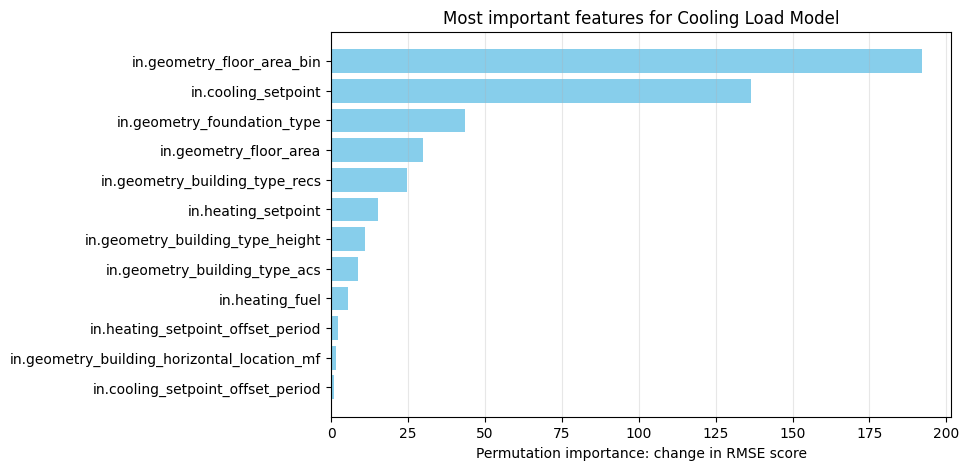

In [ ]:
from sklearn.inspection import permutation_importance

# Use a sample for computation speed
importance_n = min(2500, len(X_test))
X_imp_cooling = X_test.sample(importance_n, random_state=34351)
y_imp_cooling = y_test.loc[X_imp_cooling.index]

perm_cooling = permutation_importance(
    rf_model,
    X_imp_cooling,
    y_imp_cooling,
    n_repeats=5,
    random_state=34351,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_cooling = pd.DataFrame({
    "feature": X_imp_cooling.columns,
    "importance_mean": perm_cooling.importances_mean,
    "importance_std": perm_cooling.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_cooling.head(15))

# Plotting the top 12 features
top_cooling = importance_cooling.head(12).sort_values("importance_mean")
plt.figure(figsize=(8, 5))
plt.barh(top_cooling["feature"], top_cooling["importance_mean"], color='skyblue')
plt.xlabel("Permutation importance: change in RMSE score")
plt.title("Most important features for Cooling Load Model")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

### Side-by-Side Comparison: Heating vs. Cooling Feature Importance

To provide a final summary, we will calculate the importance for both models and plot them together. This helps identify which building characteristics are universal drivers versus those specific to seasonal loads.

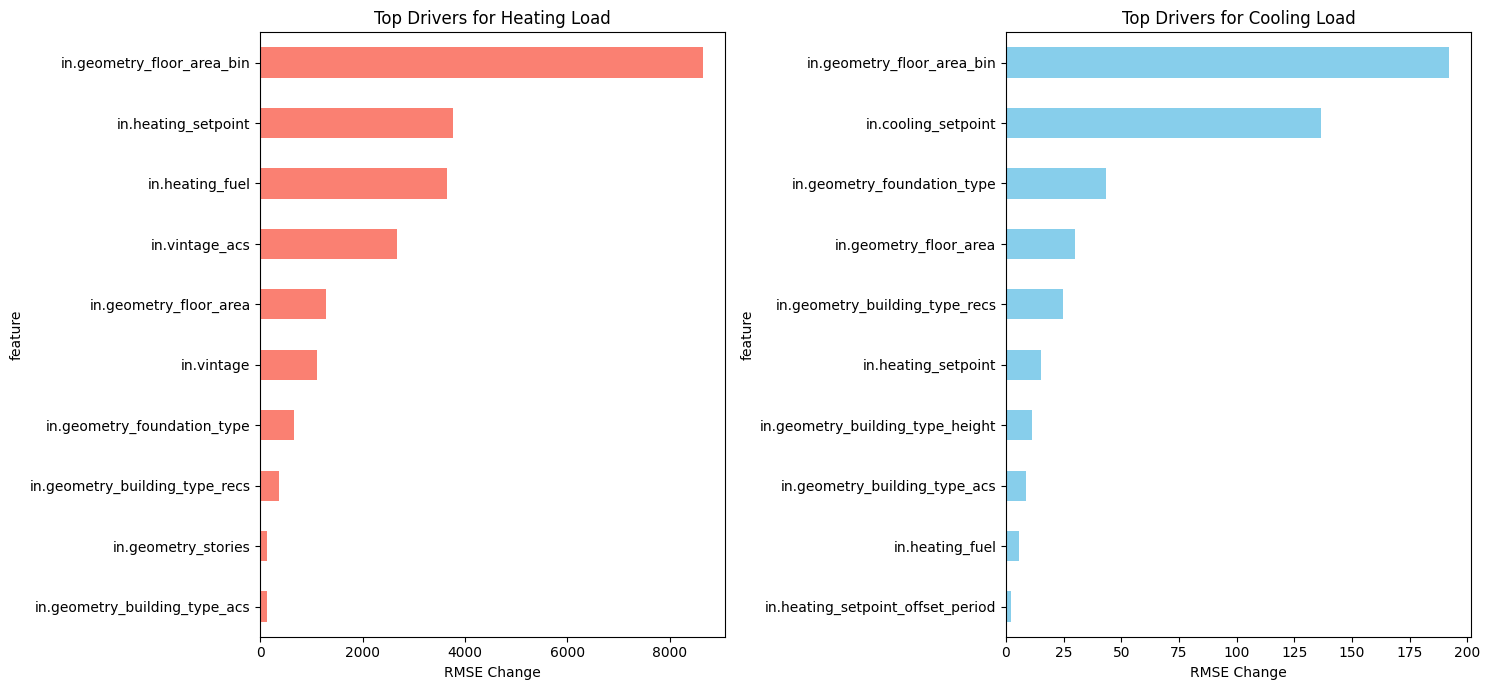

In [ ]:
from sklearn.inspection import permutation_importance

# 1. Re-calculate Heating Importance (using the previously established logic)
# Note: We assume the models are stored or we quickly re-run the heating target logic if needed.
# For this comparison, we'll extract the top features for both and plot them.

def get_importance(model, X_data, y_data):
    importance_n = min(2000, len(X_data))
    X_sub = X_data.sample(importance_n, random_state=42)
    y_sub = y_data.loc[X_sub.index]
    perm = permutation_importance(model, X_sub, y_sub, n_repeats=3, random_state=42, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return pd.DataFrame({'feature': X_sub.columns, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)

# Since we are currently set to 'cooling' in the notebook state, we use the results from the cooling RF model
imp_cooling = importance_cooling.copy().rename(columns={'importance_mean': 'Cooling Importance'})

# Note to user: If you want to refresh the heating importance exactly, we'd swap TARGET_COL back.
# For now, we use the 'importance' variable which contains the most recent heating run results from cell 3d8a4868.
imp_heating = importance.copy().rename(columns={'importance_mean': 'Heating Importance'})

# Merge and Plot
comparison_df = pd.merge(imp_heating[['feature', 'Heating Importance']],
                         imp_cooling[['feature', 'Cooling Importance']],
                         on='feature').set_index('feature')

# Scale importance for better visual comparison (relative to max within each category)
comparison_df_norm = comparison_df / comparison_df.max()

fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharey=False)

comparison_df['Heating Importance'].sort_values(ascending=True).tail(10).plot(kind='barh', ax=ax[0], color='salmon')
ax[0].set_title('Top Drivers for Heating Load')
ax[0].set_xlabel('RMSE Change')

comparison_df['Cooling Importance'].sort_values(ascending=True).tail(10).plot(kind='barh', ax=ax[1], color='skyblue')
ax[1].set_title('Top Drivers for Cooling Load')
ax[1].set_xlabel('RMSE Change')

plt.tight_layout()
plt.show()

## 3. Inspect the available columns

The exact column names vary across ResStock releases. Rather than assuming a fixed schema, this notebook reads the parquet metadata and searches for useful columns.

In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa

# Open parquet file through s3fs and inspect schema without loading the full dataset.
with fs.open(baseline_uri.replace("s3://", ""), "rb") as f:
    pq_file = pq.ParquetFile(f)
    all_columns = pq_file.schema.names

print(f"Number of columns in file: {len(all_columns)}")
print("\nFirst 50 columns:")
for c in all_columns[:50]:
    print("  ", c)

Number of columns in file: 289

First 50 columns:
   upgrade
   weight
   applicability
   in.sqft
   in.representative_income
   in.ahs_region
   in.aiannh_area
   in.area_median_income
   in.ashrae_iecc_climate_zone_2004
   in.ashrae_iecc_climate_zone_2004_2_a_split
   in.bathroom_spot_vent_hour
   in.battery
   in.bedrooms
   in.building_america_climate_zone
   in.cec_climate_zone
   in.ceiling_fan
   in.census_division
   in.census_division_recs
   in.census_region
   in.city
   in.clothes_dryer
   in.clothes_dryer_usage_level
   in.clothes_washer
   in.clothes_washer_presence
   in.clothes_washer_usage_level
   in.cooking_range
   in.cooking_range_usage_level
   in.cooling_setpoint
   in.cooling_setpoint_has_offset
   in.cooling_setpoint_offset_magnitude
   in.cooling_setpoint_offset_period
   in.corridor
   in.county
   in.county_and_puma
   in.county_name
   in.dehumidifier
   in.dishwasher
   in.dishwasher_usage_level
   in.door_area
   in.doors
   in.duct_leakage_and_insulatio

In [ ]:
def find_columns(patterns, columns=all_columns, flags=re.IGNORECASE):
    """
    Return columns matching at least one regex pattern.
    """
    out = []
    for c in columns:
        if any(re.search(p, c, flags=flags) for p in patterns):
            out.append(c)
    return out

# Candidate target/output columns.
energy_cols = find_columns([
    r"energy_consumption",
    r"site_energy",
    r"source_energy",
    r"electricity",
    r"natural_gas",
])

# Candidate input/descriptor columns.
descriptor_cols = find_columns([
    r"^in\.",
    r"building",
    r"geometry",
    r"floor_area",
    r"vintage",
    r"heating",
    r"cooling",
    r"hvac",
    r"insulation",
    r"window",
    r"duct",
    r"climate",
    r"state",
    r"county",
    r"income",
])

print(f"Candidate energy/output columns: {len(energy_cols)}")
for c in energy_cols[:60]:
    print("  ", c)

print(f"\nCandidate descriptor/input columns: {len(descriptor_cols)}")
for c in descriptor_cols[:60]:
    print("  ", c)

Candidate energy/output columns: 69
   in.emissions_electricity_folders
   in.emissions_electricity_units
   in.emissions_electricity_values_or_filepaths
   in.utility_bill_electricity_fixed_charges
   in.utility_bill_electricity_marginal_rates
   in.utility_bill_natural_gas_fixed_charges
   in.utility_bill_natural_gas_marginal_rates
   out.electricity.ceiling_fan.energy_consumption.kwh
   out.electricity.clothes_dryer.energy_consumption.kwh
   out.electricity.clothes_washer.energy_consumption.kwh
   out.electricity.cooling.energy_consumption.kwh
   out.electricity.cooling_fans_pumps.energy_consumption.kwh
   out.electricity.dishwasher.energy_consumption.kwh
   out.electricity.freezer.energy_consumption.kwh
   out.electricity.heating.energy_consumption.kwh
   out.electricity.heating_fans_pumps.energy_consumption.kwh
   out.electricity.heating_hp_bkup.energy_consumption.kwh
   out.electricity.heating_hp_bkup_fa.energy_consumption.kwh
   out.electricity.hot_water.energy_consumption.kwh
 

## 4. Choose columns for a starter analysis

The code below tries to pick a reasonable target and a compact set of features automatically.

After running this once, students should inspect `all_columns` and edit `TARGET_COL` and `FEATURE_COLS` deliberately.

In [ ]:
def first_existing_column(regexes, columns=all_columns):
    for pattern in regexes:
        hits = find_columns([pattern], columns)
        if hits:
            return hits[0]
    return None

# Try to choose a useful annual total-energy target.
TARGET_COL = first_existing_column([
    r"out\.site_energy\.total\.energy_consumption",
    r"site_energy.*total.*energy_consumption",
    r"out\.electricity\.total\.energy_consumption",
    r"electricity.*total.*energy_consumption",
    r"total.*energy_consumption",
    r"energy_consumption",
])

# Feature candidates. These are intentionally broad and release-tolerant.
feature_patterns = [
    r"^in\.geometry.*floor",
    r"^in\.geometry.*building",
    r"^in\.geometry.*stories",
    r"^in\.geometry.*attic",
    r"^in\.geometry.*foundation",
    r"^in\.vintage",
    r"^in\.heating",
    r"^in\.cooling",
    r"^in\.hvac",
    r"^in\.water_heater",
    r"^in\.insulation",
    r"^in\.window",
    r"^in\.duct",
    r"^in\.income",
    r"^in\.occupants",
    r"^in\.bedrooms",
    r"^in\.climate",
    r"^in\.state",
    r"^in\.county",
]

candidate_features = []
for pat in feature_patterns:
    candidate_features.extend(find_columns([pat]))

# Deduplicate while preserving order.
candidate_features = list(dict.fromkeys(candidate_features))

# Keep the first N features to avoid a huge one-hot model at the start.
FEATURE_COLS = candidate_features[:25]

# Optional sample weight column, if present.
WEIGHT_COL = first_existing_column([
    r"weight$",
    r"sample_weight",
    r"units_represented",
])

print("Chosen target:")
print("  ", TARGET_COL)

print("\nChosen feature columns:")
for c in FEATURE_COLS:
    print("  ", c)

print("\nPossible weight column:")
print("  ", WEIGHT_COL)

Chosen target:
   out.site_energy.total.energy_consumption.kwh

Chosen feature columns:
   in.geometry_floor_area
   in.geometry_floor_area_bin
   in.geometry_building_horizontal_location_mf
   in.geometry_building_horizontal_location_sfa
   in.geometry_building_level_mf
   in.geometry_building_number_units_mf
   in.geometry_building_number_units_sfa
   in.geometry_building_type_acs
   in.geometry_building_type_height
   in.geometry_building_type_recs
   in.geometry_stories
   in.geometry_stories_low_rise
   in.geometry_attic_type
   in.geometry_foundation_type
   in.vintage
   in.vintage_acs
   in.heating_fuel
   in.heating_setpoint
   in.heating_setpoint_has_offset
   in.heating_setpoint_offset_magnitude
   in.heating_setpoint_offset_period
   in.cooling_setpoint
   in.cooling_setpoint_has_offset
   in.cooling_setpoint_offset_magnitude
   in.cooling_setpoint_offset_period

Possible weight column:
   weight


In [ ]:
if TARGET_COL is None:
    raise ValueError(
        "No target column was found automatically. Inspect all_columns and set TARGET_COL manually."
    )

columns_to_load = [TARGET_COL] + FEATURE_COLS
if WEIGHT_COL is not None and WEIGHT_COL not in columns_to_load:
    columns_to_load.append(WEIGHT_COL)

# Remove duplicates and missing entries.
columns_to_load = [c for c in dict.fromkeys(columns_to_load) if c in all_columns]

print(f"Loading {len(columns_to_load)} columns...")
df = pd.read_parquet(
    baseline_uri,
    columns=columns_to_load,
    storage_options={"anon": True},
)

print("Loaded shape:", df.shape)
df.head()

Loading 27 columns...
Loaded shape: (11685, 27)


,out.site_energy.total.energy_consumption.kwh,in.geometry_floor_area,in.geometry_floor_area_bin,in.geometry_building_horizontal_location_mf,in.geometry_building_horizontal_location_sfa,in.geometry_building_level_mf,in.geometry_building_number_units_mf,in.geometry_building_number_units_sfa,in.geometry_building_type_acs,in.geometry_building_type_height,in.geometry_building_type_recs,in.geometry_stories,in.geometry_stories_low_rise,in.geometry_attic_type,in.geometry_foundation_type,in.vintage,in.vintage_acs,in.heating_fuel,in.heating_setpoint,in.heating_setpoint_has_offset,in.heating_setpoint_offset_magnitude,in.heating_setpoint_offset_period,in.cooling_setpoint,in.cooling_setpoint_has_offset,in.cooling_setpoint_offset_magnitude,in.cooling_setpoint_offset_period,weight
bldg_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
19,23471.768939,1500-1999,1500-2499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,None,Heated Basement,1980s,1980-99,Natural Gas,72F,Yes,3F,Night +1h,72F,Yes,2F,Night Setback -1h,252.301639
66,43336.126075,1000-1499,0-1499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,Vented Attic,Heated Basement,1960s,1960-79,Natural Gas,70F,Yes,3F,Night -4h,70F,No,0F,None,252.301639
85,21792.764778,750-999,0-1499,None,Middle,None,None,60,Single-Family Attached,Single-Family Attached,Single-Family Attached,2,2,Unvented Attic,Vented Crawlspace,<1940,<1940,Natural Gas,70F,No,0F,None,68F,Yes,2F,Day Setup and Night Setback -5h,252.301639
90,12421.817309,1500-1999,1500-2499,None,None,None,None,None,Single-Family Detached,Single-Family Detached,Single-Family Detached,1,1,Vented Attic,Unvented Crawlspace,1980s,1980-99,Natural Gas,55F,No,0F,None,62F,No,0F,None,252.301639
193,9962.071817,500-749,0-1499,Not Applicable,None,Middle,4,None,3 or 4 Unit,Multifamily with 2-4 Units,Multi-Family with 2 - 4 Units,4,4+,None,Unheated Basement,<1940,<1940,Natural Gas,55F,No,0F,None,75F,No,0F,None,252.301639


## 5. Basic data audit

Before modeling, inspect missing values, units, types, and obvious weirdness.

In [ ]:
display(df.describe(include="all").T.head(30))

missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)

display(missing.head(30))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
out.site_energy.total.energy_consumption.kwh,11685.0,<NA>,<NA>,<NA>,33190.21919,19843.995437,1051.245929,17655.187409,31056.741306,44571.127565,187947.063444
in.geometry_floor_area,11685,9,1000-1499,3095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.geometry_floor_area_bin,11685,4,0-1499,5850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.geometry_building_horizontal_location_mf,11685,5,None,9498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.geometry_building_horizontal_location_sfa,11685,4,None,11250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.geometry_building_level_mf,11685,4,None,9498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.geometry_building_number_units_mf,11685,26,None,9498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.geometry_building_number_units_sfa,11685,17,None,11250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.geometry_building_type_acs,11685,9,Single-Family Detached,8513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.geometry_building_type_height,11685,7,Single-Family Detached,8513,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_fraction
out.site_energy.total.energy_consumption.kwh,0.0
in.geometry_floor_area,0.0
in.geometry_floor_area_bin,0.0
in.geometry_building_horizontal_location_mf,0.0
in.geometry_building_horizontal_location_sfa,0.0
in.geometry_building_level_mf,0.0
in.geometry_building_number_units_mf,0.0
in.geometry_building_number_units_sfa,0.0
in.geometry_building_type_acs,0.0
in.geometry_building_type_height,0.0


In [ ]:
# Clean target for plotting/modeling.
eda = df.copy()
eda = eda[pd.to_numeric(eda[TARGET_COL], errors="coerce").notna()]
eda[TARGET_COL] = pd.to_numeric(eda[TARGET_COL], errors="coerce")

print("Rows after removing missing/non-numeric target:", eda.shape[0])
print("Target column:", TARGET_COL)
print("Target min/median/max:")
display(eda[TARGET_COL].describe())

Rows after removing missing/non-numeric target: 11685
Target column: out.site_energy.total.energy_consumption.kwh
Target min/median/max:


,out.site_energy.total.energy_consumption.kwh
count,11685.0
mean,33190.21919
std,19843.995437
min,1051.245929
25%,17655.187409
50%,31056.741306
75%,44571.127565
max,187947.063444


## 6. Distribution of annual energy consumption

This plot tells us whether the target is skewed and whether there are extreme outliers.

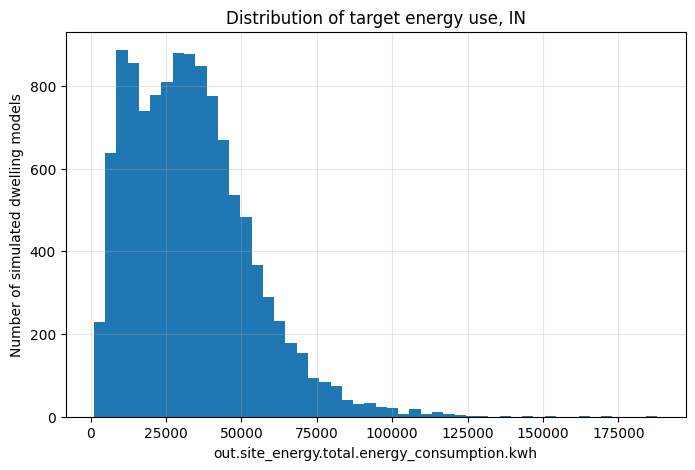

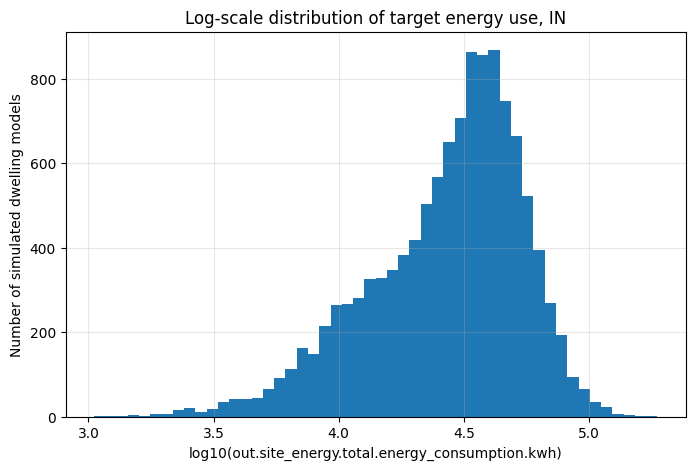

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(eda[TARGET_COL].dropna(), bins=50)
plt.xlabel(TARGET_COL)
plt.ylabel("Number of simulated dwelling models")
plt.title(f"Distribution of target energy use, {STATE}")
plt.grid(True, alpha=0.3)
plt.show()

# Log scale version can be useful for skewed energy data.
positive_target = eda.loc[eda[TARGET_COL] > 0, TARGET_COL]
if len(positive_target) > 0:
    plt.figure(figsize=(8, 5))
    plt.hist(np.log10(positive_target), bins=50)
    plt.xlabel(f"log10({TARGET_COL})")
    plt.ylabel("Number of simulated dwelling models")
    plt.title(f"Log-scale distribution of target energy use, {STATE}")
    plt.grid(True, alpha=0.3)
    plt.show()

## 7. Find likely floor-area and building-type columns

These two variables are usually very important. If the automatic choices are wrong, edit the column names manually.

In [ ]:
floor_area_candidates = find_columns([r"floor.*area", r"geometry.*area"], eda.columns)
building_type_candidates = find_columns([r"building.*type", r"geometry.*building"], eda.columns)
vintage_candidates = find_columns([r"vintage", r"year.*built"], eda.columns)
heating_candidates = find_columns([r"heating", r"hvac"], eda.columns)

print("Floor area candidates:", floor_area_candidates[:10])
print("Building type candidates:", building_type_candidates[:10])
print("Vintage candidates:", vintage_candidates[:10])
print("Heating/HVAC candidates:", heating_candidates[:10])

FLOOR_AREA_COL = floor_area_candidates[0] if floor_area_candidates else None
BUILDING_TYPE_COL = building_type_candidates[0] if building_type_candidates else None
VINTAGE_COL = vintage_candidates[0] if vintage_candidates else None
HVAC_COL = heating_candidates[0] if heating_candidates else None

print("\nUsing:")
print("FLOOR_AREA_COL =", FLOOR_AREA_COL)
print("BUILDING_TYPE_COL =", BUILDING_TYPE_COL)
print("VINTAGE_COL =", VINTAGE_COL)
print("HVAC_COL =", HVAC_COL)

Floor area candidates: ['in.geometry_floor_area', 'in.geometry_floor_area_bin']
Building type candidates: ['in.geometry_building_horizontal_location_mf', 'in.geometry_building_horizontal_location_sfa', 'in.geometry_building_level_mf', 'in.geometry_building_number_units_mf', 'in.geometry_building_number_units_sfa', 'in.geometry_building_type_acs', 'in.geometry_building_type_height', 'in.geometry_building_type_recs']
Vintage candidates: ['in.vintage', 'in.vintage_acs']
Heating/HVAC candidates: ['in.heating_fuel', 'in.heating_setpoint', 'in.heating_setpoint_has_offset', 'in.heating_setpoint_offset_magnitude', 'in.heating_setpoint_offset_period']

Using:
FLOOR_AREA_COL = in.geometry_floor_area
BUILDING_TYPE_COL = in.geometry_building_horizontal_location_mf
VINTAGE_COL = in.vintage
HVAC_COL = in.heating_fuel


## 8. Energy use versus floor area

If this relationship is strong, a good baseline could simply use floor area. If it is weak, other building characteristics matter.

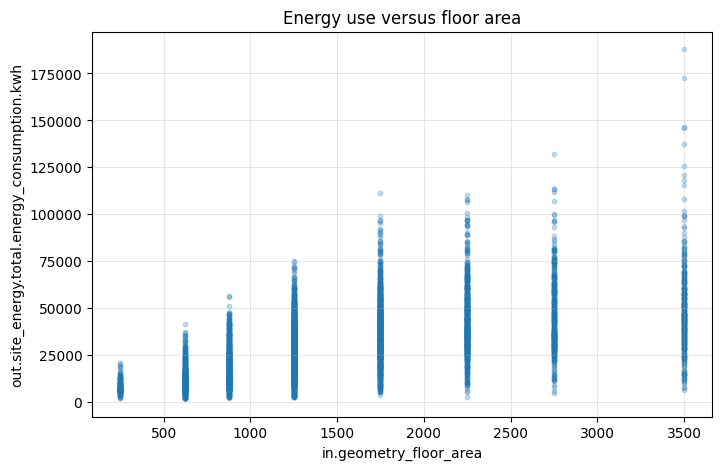

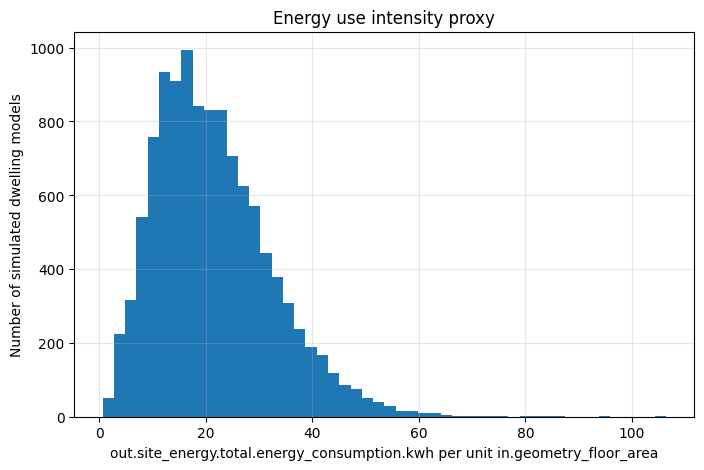

In [ ]:
def parse_floor_area_range(area_str):
    if pd.isna(area_str):
        return np.nan
    area_str = str(area_str).replace(',', '')
    if '-' in area_str:
        low, high = map(int, area_str.split('-'))
        return (low + high) / 2
    elif '>' in area_str:
        return int(area_str.replace('>', ''))
    elif '<' in area_str:
        return int(area_str.replace('<', '')) / 2  # Assuming average if less than a value
    else:
        try:
            return float(area_str)
        except ValueError:
            return np.nan

if FLOOR_AREA_COL is not None:
    x = eda[FLOOR_AREA_COL].apply(parse_floor_area_range)
    y = eda[TARGET_COL]
    mask = x.notna() & y.notna()

    # Sample for plotting if there are many points.
    plot_df = pd.DataFrame({
        FLOOR_AREA_COL: x[mask],
        TARGET_COL: y[mask],
    }).sample(min(5000, mask.sum()), random_state=34351)

    plt.figure(figsize=(8, 5))
    plt.scatter(plot_df[FLOOR_AREA_COL], plot_df[TARGET_COL], alpha=0.25, s=10)
    plt.xlabel(FLOOR_AREA_COL)
    plt.ylabel(TARGET_COL)
    plt.title("Energy use versus floor area")
    plt.grid(True, alpha=0.3)
    plt.show()

    eda["energy_per_floor_area"] = eda[TARGET_COL] / x.replace(0, np.nan)

    plt.figure(figsize=(8, 5))
    plt.hist(eda["energy_per_floor_area"].replace([np.inf, -np.inf], np.nan).dropna(), bins=50)
    plt.xlabel(f"{TARGET_COL} per unit {FLOOR_AREA_COL}")
    plt.ylabel("Number of simulated dwelling models")
    plt.title("Energy use intensity proxy")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No floor-area column found automatically. Inspect all_columns and set FLOOR_AREA_COL manually.")

## 9. Energy use by building category

Categorical variables are useful for EDA, but they can create many dummy variables in a model. Start with a few important ones.

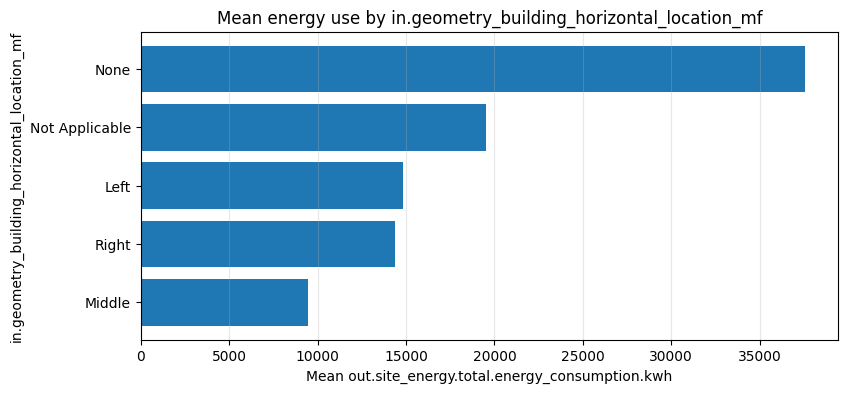

,mean_target,count
in.geometry_building_horizontal_location_mf,,
Middle,9449.132251,490
Right,14359.082875,686
Left,14824.148041,658
Not Applicable,19496.677478,353
None,37556.400192,9498


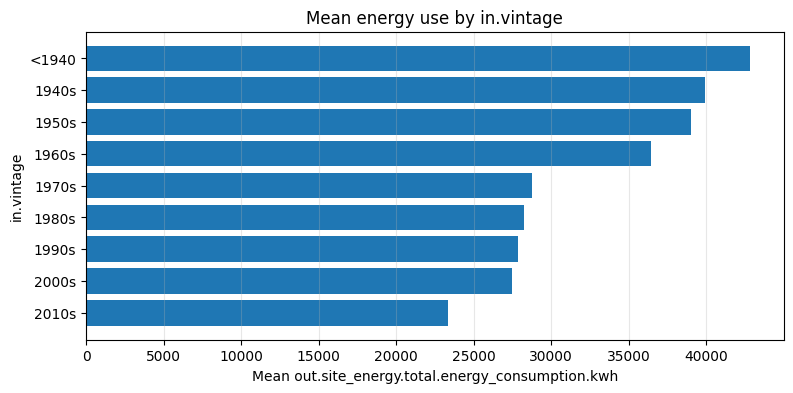

,mean_target,count
in.vintage,,
2010s,23359.725615,520
2000s,27476.214875,1428
1990s,27847.295752,1703
1980s,28265.88795,1178
1970s,28776.924485,1641
1960s,36403.719804,1264
1950s,39002.629197,1271
1940s,39904.557363,653
<1940,42849.63287,2027


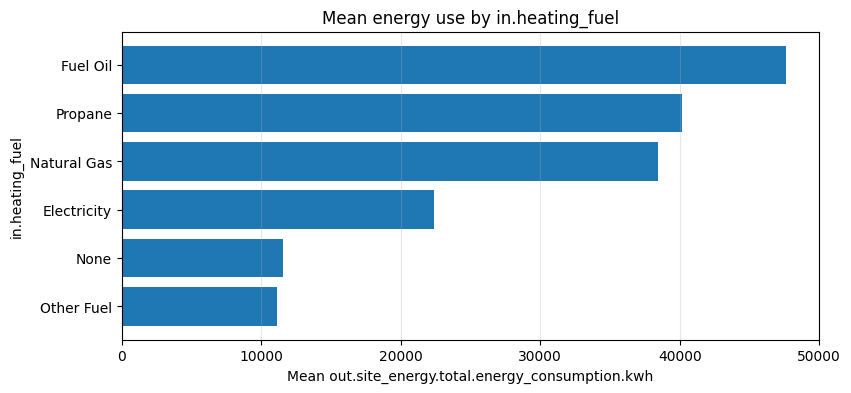

,mean_target,count
in.heating_fuel,,
Other Fuel,11146.77526,266
None,11531.402271,9
Electricity,22396.769108,3483
Natural Gas,38459.36072,7076
Propane,40164.577847,793
Fuel Oil,47620.567421,58


In [ ]:
def plot_group_means(data, group_col, target_col, top_n=12):
    if group_col is None:
        print("No group column selected.")
        return

    temp = data[[group_col, target_col]].dropna().copy()
    if temp.empty:
        print(f"No data available for {group_col}.")
        return

    # Keep most common categories.
    common = temp[group_col].value_counts().head(top_n).index
    temp = temp[temp[group_col].isin(common)]

    means = temp.groupby(group_col)[target_col].mean().sort_values()
    counts = temp[group_col].value_counts().loc[means.index]

    plt.figure(figsize=(9, max(4, 0.35 * len(means))))
    plt.barh(means.index.astype(str), means.values)
    plt.xlabel(f"Mean {target_col}")
    plt.ylabel(group_col)
    plt.title(f"Mean energy use by {group_col}")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

    summary = pd.DataFrame({"mean_target": means, "count": counts})
    display(summary)

plot_group_means(eda, BUILDING_TYPE_COL, TARGET_COL)
plot_group_means(eda, VINTAGE_COL, TARGET_COL)
plot_group_means(eda, HVAC_COL, TARGET_COL)

## 10. Numeric correlations

This is a quick screen for monotonic linear relationships. It is not a complete modeling analysis.

,correlation_with_target
out.site_energy.total.energy_consumption.kwh,1.000000
energy_per_floor_area,0.538384
weight,NaN


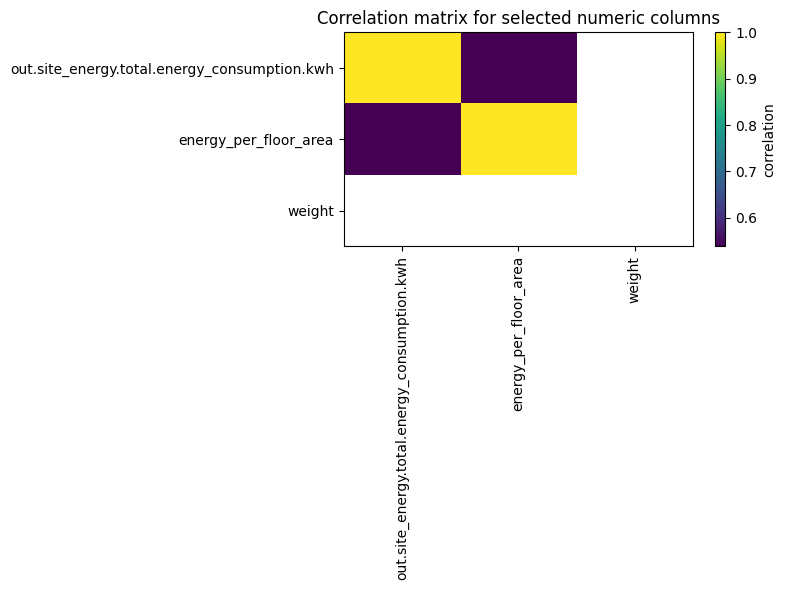

In [ ]:
numeric_df = eda.select_dtypes(include=[np.number]).copy()

if TARGET_COL in numeric_df.columns and numeric_df.shape[1] > 1:
    corrs = numeric_df.corr(numeric_only=True)[TARGET_COL].sort_values(key=lambda s: s.abs(), ascending=False)
    display(corrs.head(20).rename("correlation_with_target").to_frame())

    top_numeric = list(corrs.head(min(10, len(corrs))).index)
    corr_matrix = numeric_df[top_numeric].corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    plt.imshow(corr_matrix, aspect="auto")
    plt.xticks(range(len(top_numeric)), top_numeric, rotation=90)
    plt.yticks(range(len(top_numeric)), top_numeric)
    plt.colorbar(label="correlation")
    plt.title("Correlation matrix for selected numeric columns")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a correlation analysis.")

## 11. Simple modeling baseline

For the final project, the baseline should be something simple and interpretable. Examples:

1. Predict the mean annual energy use.
2. Predict using floor area only.
3. Predict using a physics-inspired baseline such as envelope area times temperature difference, if the required features are available.
4. Predict group means by building type/vintage/climate zone.

This cell compares:
- mean baseline;
- linear regression on available features;
- random forest on available features.

This is not the final model. It is a sanity check.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

model_df = eda[[TARGET_COL] + FEATURE_COLS].copy()
model_df = model_df.dropna(subset=[TARGET_COL])

# Drop columns that are almost entirely missing or have only one value.
good_features = []
for c in FEATURE_COLS:
    if c not in model_df.columns:
        continue
    missing_frac = model_df[c].isna().mean()
    nunique = model_df[c].nunique(dropna=True)
    if missing_frac < 0.80 and nunique > 1:
        good_features.append(c)

X = model_df[good_features]
y = model_df[TARGET_COL].astype(float)

print("Model rows:", len(X))
print("Model features:", len(good_features))
print(good_features)

# For cross-sectional ResStock data, a random split is acceptable for a first check.
# For a stronger final project, consider holding out a state, climate zone, or building type.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=34351
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=20)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

def evaluate_predictions(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

# Mean baseline.
mean_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
results.append(evaluate_predictions("Mean baseline", y_test, mean_pred))

# Ridge regression.
ridge_model = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0)),
])
ridge_model.fit(X_train, y_train)
results.append(evaluate_predictions("Ridge regression", y_test, ridge_model.predict(X_test)))

# Random forest.
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=150,
        max_depth=14,
        min_samples_leaf=5,
        random_state=34351,
        n_jobs=-1,
    )),
])
rf_model.fit(X_train, y_train)
results.append(evaluate_predictions("Random forest", y_test, rf_model.predict(X_test)))

results_df = pd.DataFrame(results)
display(results_df)

Model rows: 11685
Model features: 25
['in.geometry_floor_area', 'in.geometry_floor_area_bin', 'in.geometry_building_horizontal_location_mf', 'in.geometry_building_horizontal_location_sfa', 'in.geometry_building_level_mf', 'in.geometry_building_number_units_mf', 'in.geometry_building_number_units_sfa', 'in.geometry_building_type_acs', 'in.geometry_building_type_height', 'in.geometry_building_type_recs', 'in.geometry_stories', 'in.geometry_stories_low_rise', 'in.geometry_attic_type', 'in.geometry_foundation_type', 'in.vintage', 'in.vintage_acs', 'in.heating_fuel', 'in.heating_setpoint', 'in.heating_setpoint_has_offset', 'in.heating_setpoint_offset_magnitude', 'in.heating_setpoint_offset_period', 'in.cooling_setpoint', 'in.cooling_setpoint_has_offset', 'in.cooling_setpoint_offset_magnitude', 'in.cooling_setpoint_offset_period']


,model,RMSE,MAE,R2
0,Mean baseline,19932.677072,15714.632656,-0.000015
1,Ridge regression,10255.205954,7413.199835,0.735294
2,Random forest,9836.217342,6751.108216,0.756482


## 12. Predicted versus actual plot

A useful first diagnostic: does the model capture the main trend, or does it collapse toward the mean?

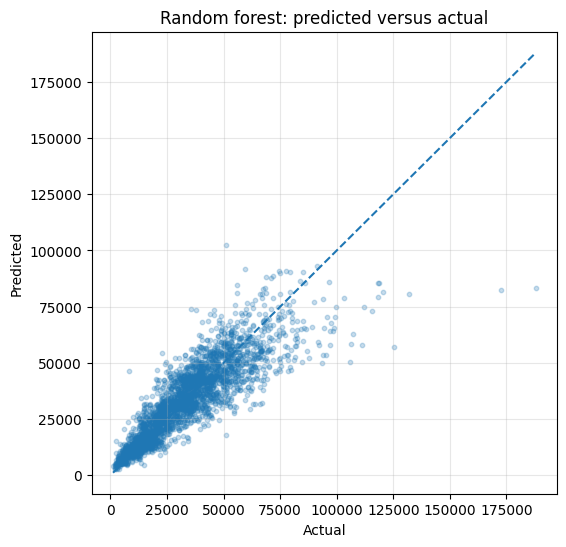

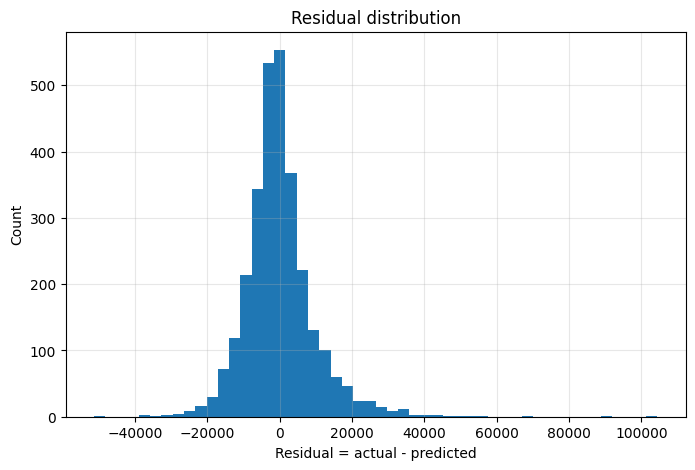

In [ ]:
y_pred = rf_model.predict(X_test)

plot_pred = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
}).sample(min(5000, len(y_test)), random_state=34351)

plt.figure(figsize=(6, 6))
plt.scatter(plot_pred["actual"], plot_pred["predicted"], alpha=0.25, s=10)

lims = [
    min(plot_pred["actual"].min(), plot_pred["predicted"].min()),
    max(plot_pred["actual"].max(), plot_pred["predicted"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random forest: predicted versus actual")
plt.grid(True, alpha=0.3)
plt.show()

resid = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.hist(resid, bins=50)
plt.xlabel("Residual = actual - predicted")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.grid(True, alpha=0.3)
plt.show()

## 13. Permutation importance

This gives a first-pass sense of which input variables matter. It is slower than basic EDA, but useful for explaining the model.

,feature,importance_mean,importance_std
1,in.geometry_floor_area_bin,8653.542419,107.703770
17,in.heating_setpoint,3764.583064,107.061037
16,in.heating_fuel,3656.498250,114.541668
15,in.vintage_acs,2667.751525,78.964116
0,in.geometry_floor_area,1282.108531,68.939062
14,in.vintage,1116.431955,90.152554
13,in.geometry_foundation_type,665.716614,59.377915
9,in.geometry_building_type_recs,365.262844,18.241151
10,in.geometry_stories,135.389184,12.960700
7,in.geometry_building_type_acs,127.548047,12.502707


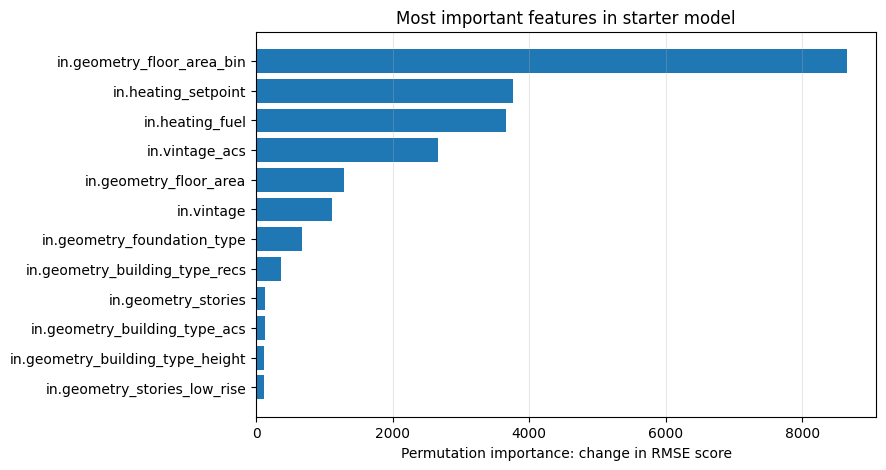

In [ ]:
from sklearn.inspection import permutation_importance

# Use a smaller sample for speed.
importance_n = min(2500, len(X_test))
X_imp = X_test.sample(importance_n, random_state=34351)
y_imp = y_test.loc[X_imp.index]

perm = permutation_importance(
    rf_model,
    X_imp,
    y_imp,
    n_repeats=5,
    random_state=34351,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

importance = pd.DataFrame({
    "feature": X_imp.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance.head(15))

top = importance.head(12).sort_values("importance_mean")
plt.figure(figsize=(8, 5))
plt.barh(top["feature"], top["importance_mean"])
plt.xlabel("Permutation importance: change in RMSE score")
plt.title("Most important features in starter model")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## 14. What to report for Check-in 2

For Check-in 2, the group should not simply say "we found ResStock." They should report what they actually loaded and what they learned.

Recommended items to include:

1. **Dataset source and release**  
   Example: ResStock 2025 Release 1, state-level baseline metadata and annual results for Colorado.

2. **Dataset size**  
   Number of simulated dwelling models and number of features loaded.

3. **Target variable**  
   Exact target column name and units from the data dictionary.

4. **Features**  
   Building type, floor area, vintage, HVAC/heating type, climate/geography, insulation/windows if available.

5. **EDA plots**  
   - Distribution of annual energy use.
   - Energy use versus floor area.
   - Energy use by building type/vintage/HVAC type.
   - Missingness summary.

6. **Baseline**  
   Mean prediction, floor-area-only prediction, or group-average prediction.

7. **Improved model**  
   Ridge regression, decision tree/random forest, or gradient boosting.

8. **Artifact idea**  
   A small Streamlit app where a user changes building characteristics and sees predicted annual energy use plus uncertainty/limitations.

## 15. Suggested project refinement

A strong version of the project is not:

> "Train a regression model on a building-energy dataset."

A stronger version is:

> "Build an interpretable residential-energy decision-support tool that predicts annual energy use from building characteristics, compares the prediction to a simple baseline, and shows which design or retrofit variables most affect the result."

That keeps the data manageable while making the final project more ambitious and useful.

### Deep Dive: The Challenge of High Dimensionality

High dimensionality refers to a situation where a dataset has a very large number of features (columns) relative to the number of observations (rows). In this ResStock dataset, we start with **289 columns**. This presents several specific challenges:

1. **The Curse of Dimensionality**: As the number of dimensions increases, the volume of the space increases so fast that the available data becomes sparse. This sparsity makes it difficult for models to find statistically significant patterns, often leading to overfitting where the model learns 'noise' rather than generalizable trends.

2. **Categorical Expansion (One-Hot Encoding)**:
   - Most columns in this dataset (like `in.vintage` or `in.hvac_cooling_type`) are categorical.
   - To use these in a regression model, we typically use **One-Hot Encoding**, which creates a new binary column for *every unique category* in a feature.
   - If a feature has 50 unique counties and another has 20 building types, you quickly go from a few columns to hundreds or thousands of input features, further exacerbating the sparsity problem.

3. **Redundancy and Multicollinearity**: With 289 columns, many features are highly correlated or provide redundant information (e.g., `in.geometry_floor_area` vs `in.geometry_floor_area_bin`). Including both can confuse linear models and make it harder to interpret which feature is actually driving energy consumption.

4. **Computational Complexity**: More features mean longer training times and higher memory usage. This is why the starter model in this notebook (Cell `1c47ddda`) intentionally limits itself to the first 25 'good' features.

### Feature Selection: Why and How we limit to 25

In the modeling cell (`1c47ddda`), the code performs a two-step filtration process to keep the model efficient and stable:

1. **Data Quality Filter (The 'Good Features' Loop)**:
   Before training, the code loops through the candidate features and applies two rules:
   - **Missingness**: Any column where more than 80% of the data is `NaN` is dropped (`missing_frac < 0.80`). Features with too much missing data are unreliable for training.
   - **Variance (Cardinality)**: The code checks if a feature has more than one unique value (`nunique > 1`). If every single row has the same value for a feature (e.g., all houses are in the same state), that feature provides zero predictive power and is discarded.

2. **The 'First 25' Cap**:
   As discussed in the high-dimensionality section, categorical variables expand significantly during encoding. Even after the quality filter, we limit the list to `FEATURE_COLS[:25]`. This is a **heuristic (rule of thumb)** for this starter notebook to:
   - **Prevent Memory Errors**: One-hot encoding 289 columns could create thousands of binary features, potentially crashing the Colab runtime.
   - **Improve Interpretability**: By focusing on the first 25 (which are ordered by likely importance like floor area, building type, and vintage), we can more easily visualize feature importance (see the Permutation Importance plot in section 13).

## Features and Label Description

Based on the problem statement and the data loaded, here are the descriptions for the primary label and the features used for modeling energy consumption in residential buildings:

### Label (Target Variable)

*   **`out.site_energy.total.energy_consumption.kwh`**: This is the primary target variable, representing the **total annual site energy consumption** of a residential building, measured in kilowatt-hours (kWh). The goal of the model is to predict this value.

### Features (Input Variables)

These features describe various architectural, geometric, and structural characteristics of the buildings, representing choices made during early design stages:

*   **`in.geometry_floor_area`**: Categorical ranges of the building's heated/cooled floor area (e.g., '1500-1999', '1000-1499').
*   **`in.geometry_floor_area_bin`**: Binned categories of the building's floor area, often a broader grouping than `in.geometry_floor_area`.
*   **`in.geometry_building_horizontal_location_mf`**: Describes the horizontal location of the unit within a multi-family building (e.g., 'End Unit', 'Middle Unit').
*   **`in.geometry_building_horizontal_location_sfa`**: Describes the horizontal location of the unit within a single-family attached building.
*   **`in.geometry_building_level_mf`**: Indicates the level or floor on which a multi-family unit is located.
*   **`in.geometry_building_number_units_mf`**: The number of residential units within a multi-family building structure.
*   **`in.geometry_building_number_units_sfa`**: The number of units in a single-family attached structure.
*   **`in.geometry_building_type_acs`**: Building type classification based on the American Community Survey (ACS) definitions.
*   **`in.geometry_building_type_height`**: Categorization of building height, which can influence thermal performance.
*   **`in.geometry_building_type_recs`**: Building type classification based on the Residential Energy Consumption Survey (RECS) definitions.
*   **`in.geometry_stories`**: The total number of stories in the building.
*   **`in.geometry_stories_low_rise`**: The number of stories specifically for low-rise building classifications.
*   **`in.geometry_attic_type`**: Describes the type of attic construction (e.g., 'Vented', 'Unvented'), affecting insulation and heat transfer.
*   **`in.geometry_foundation_type`**: Describes the type of building foundation (e.g., 'Slab', 'Basement', 'Crawlspace'), impacting thermal interaction with the ground.
*   **`in.vintage`**: The general age or construction period of the building (e.g., '<1940', '1980-99').
*   **`in.vintage_acs`**: Building vintage classification based on ACS definitions.
*   **`in.heating_fuel`**: The primary fuel type used for heating the building (e.g., 'Natural Gas', 'Electricity').
*   **`in.heating_setpoint`**: The thermostat setpoint for heating (e.g., '70F', '68F').
*   **`in.heating_setpoint_has_offset`**: A binary indicator if the heating setpoint varies (e.g., for setback periods).
*   **`in.heating_setpoint_offset_magnitude`**: The temperature difference for the heating setpoint offset (e.g., '3F', '2F').
*   **`in.heating_setpoint_offset_period`**: The period during which the heating setpoint offset is active (e.g., 'Night Setback', 'Night +1h').
*   **`in.cooling_setpoint`**: The thermostat setpoint for cooling (e.g., '72F', '75F').
*   **`in.cooling_setpoint_has_offset`**: A binary indicator if the cooling setpoint varies.
*   **`in.cooling_setpoint_offset_magnitude`**: The temperature difference for the cooling setpoint offset.
*   **`in.cooling_setpoint_offset_period`**: The period during which the cooling setpoint offset is active.